Confusion Matrix:  [[13  0  0]
 [ 0 15  1]
 [ 0  3  6]]
Accuracy :  89.47368421052632
Report :                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.83      0.94      0.88        16
   virginica       0.86      0.67      0.75         9

    accuracy                           0.89        38
   macro avg       0.90      0.87      0.88        38
weighted avg       0.90      0.89      0.89        38

Confusion Matrix:  [[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
Accuracy :  97.36842105263158
Report :                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



/tmp/ipykernel_6884/4158527190.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


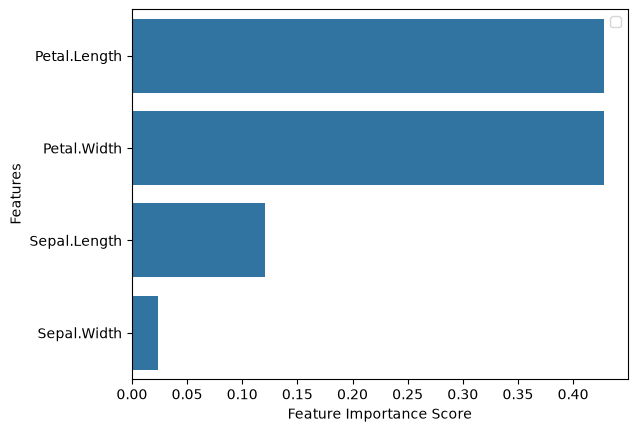

In [2]:
from sklearn.datasets import load_iris
import pandas as pd
import os
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from io import StringIO
import pydotplus
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./flowers.csv')
X = df[list(df.columns)[:-1]]
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)  

a = DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth=3, min_samples_leaf=5)  # gini 
a.fit(X_train, y_train) 
y_pred = a.predict(X_test) 
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred)) 
print ("Accuracy : ", accuracy_score(y_test,y_pred)*100) 
print("Report : ", classification_report(y_test, y_pred)) 

dot_data = StringIO()
export_graphviz(a, out_file=dot_data,filled=True, rounded=True,special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())
graph.write_png("decisiontree_gini.png")

b = RandomForestClassifier(max_depth = None, n_estimators=100)
b.fit(X_train,y_train)
y_pred = b.predict(X_test) 
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred)) 
print ("Accuracy : ", accuracy_score(y_test,y_pred)*100) 
print("Report : ", classification_report(y_test, y_pred)) 
             
export_graphviz(b.estimators_[5], out_file='tree.dot', feature_names = X_train.columns.tolist(),
                class_names = ['Lotus', 'Jasmin', 'Rose'],
                rounded = True, proportion = False, precision = 2, filled = True)
                
os.system ("dot -Tpng tree.dot -o randomforest.png -Gdpi=600")
Image(filename = 'randomforest.png')
f = pd.Series(b.feature_importances_,index=X_train.columns.tolist()).sort_values(ascending=False)
sns.barplot(x=f, y=f.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.legend()
plt.show()